In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
!pip install -q kaggle
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d data/
!unzip -o data/train.csv.zip -d data/
!unzip -o data/test.csv.zip -d data/
!unzip -o data/features.csv.zip -d data/

100% 2.70M/2.70M [00:00<00:00, 186MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: data/features.csv.zip   
  inflating: data/sampleSubmission.csv.zip  
  inflating: data/stores.csv         
  inflating: data/test.csv.zip       
  inflating: data/train.csv.zip      
Archive:  data/train.csv.zip
  inflating: data/train.csv          
Archive:  data/test.csv.zip
  inflating: data/test.csv           
Archive:  data/features.csv.zip
  inflating: data/features.csv       


In [4]:
!pip install -q dagshub mlflow==2.22.0 xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6/954.6 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import mlflow
import mlflow.sklearn

from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

pd.set_option('display.max_columns', 50)

In [6]:
import dagshub
import mlflow

dagshub.init(repo_owner='aleko-mamukashvili', repo_name='Store-Sales-Forecasting', mlflow=True)

EXPERIMENT_NAME = "XGBoost_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=dd0fa113-1d5f-4805-b670-d1621796c704&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=fd1b13bd27f69f9cf5fc64ee9e038ba63852e4577f574a245459aae0ff155628




Accessing as aleko-mamukashvili

Initialized MLflow to track repo "aleko-mamukashvili/Store-Sales-Forecasting"

Repository aleko-mamukashvili/Store-Sales-Forecasting initialized!

<Experiment: artifact_location='mlflow-artifacts:/fb6b5b3829324b9e85665c3a6ab09e1c', creation_time=1783613034717, experiment_id='1', last_update_time=1783613034717, lifecycle_stage='active', name='XGBoost_Training', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [7]:
DATA_PATH = "data"

train_raw = pd.read_csv(f"{DATA_PATH}/train.csv")
features_raw = pd.read_csv(f"{DATA_PATH}/features.csv")
stores_raw = pd.read_csv(f"{DATA_PATH}/stores.csv")

df = train_raw.merge(features_raw, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
df = df.merge(stores_raw, on='Store', how='left')

if 'IsHoliday_feat' in df.columns:
    df = df.drop(columns=['IsHoliday_feat'])

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(df.shape)
df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


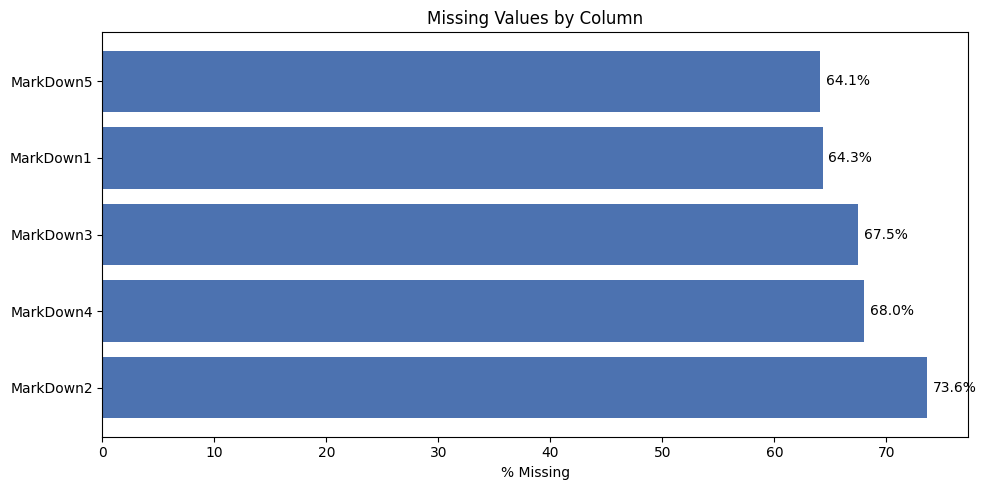

MarkDown2    310322
MarkDown4    286603
MarkDown3    284479
MarkDown1    270889
MarkDown5    270138
dtype: int64


In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing.index, missing_pct.values, color='#4C72B0')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column')
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.5, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

print(missing)

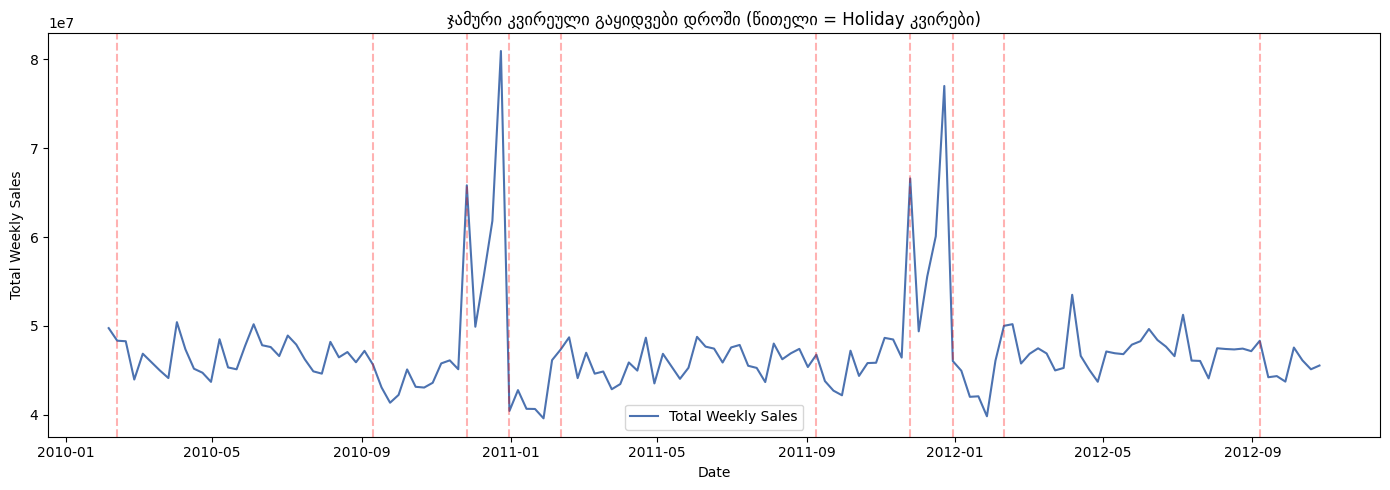

In [9]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()
holiday_dates = df[df['IsHoliday']]['Date'].unique()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_total.index, weekly_total.values, color='#4C72B0', label='Total Weekly Sales')
for hd in holiday_dates:
    ax.axvline(pd.Timestamp(hd), color='red', alpha=0.3, linestyle='--')
ax.set_title('ჯამური კვირეული გაყიდვები დროში (წითელი = Holiday კვირები)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales')
ax.legend()
plt.tight_layout()
plt.show()

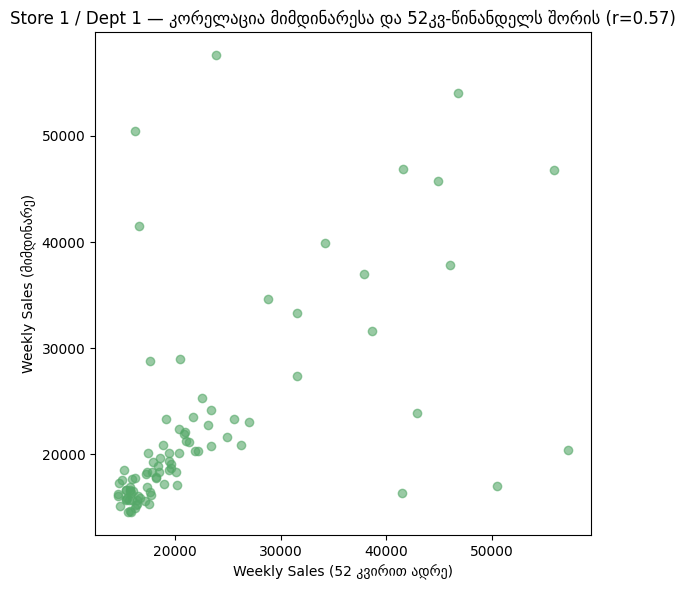

Pearson r (52-week lag) store1/dept1: 0.573


In [11]:
sample = df[(df['Store'] == 1) & (df['Dept'] == 1)].set_index('Date')['Weekly_Sales']
sample_shifted = sample.shift(freq=pd.Timedelta(weeks=52))

merged_lag_check = pd.DataFrame({
    'current': sample,
    'same_week_last_year': sample_shifted
}).dropna()

corr = merged_lag_check['current'].corr(merged_lag_check['same_week_last_year'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged_lag_check['same_week_last_year'], merged_lag_check['current'], alpha=0.6, color='#55A868')
ax.set_xlabel('Weekly Sales (52 კვირით ადრე)')
ax.set_ylabel('Weekly Sales (მიმდინარე)')
ax.set_title(f'Store 1 / Dept 1 — კორელაცია მიმდინარესა და 52კვ-წინანდელს შორის (r={corr:.2f})')
plt.tight_layout()
plt.show()

print(f"Pearson r (52-week lag) store1/dept1: {corr:.3f}")

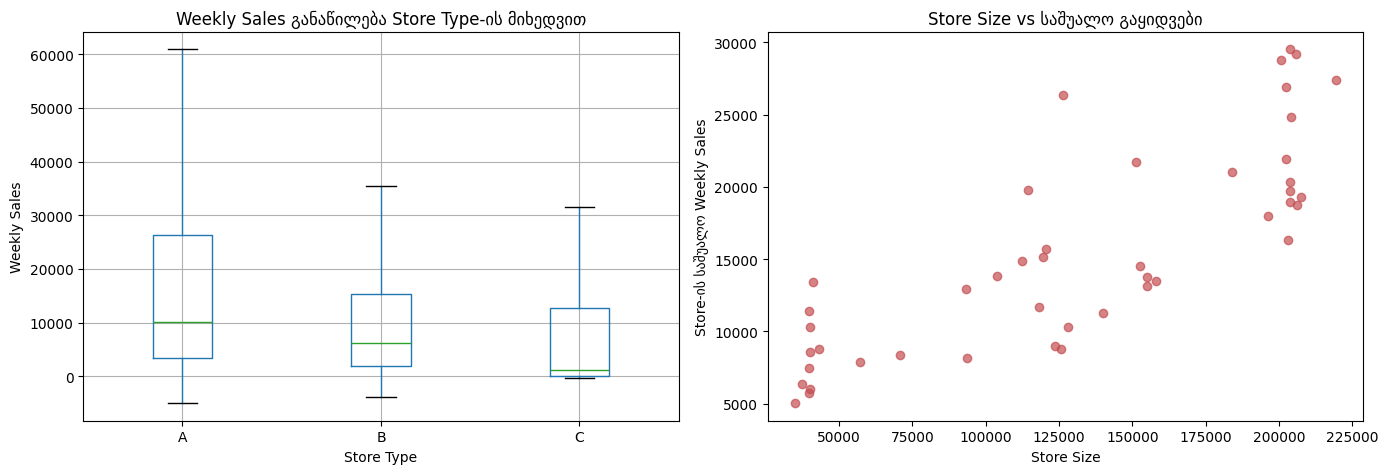

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Weekly_Sales', by='Type', ax=axes[0], showfliers=False)
axes[0].set_title('Weekly Sales განაწილება Store Type-ის მიხედვით')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Weekly Sales')

store_avg_sales = df.groupby('Store')['Weekly_Sales'].mean().reset_index()
size_vs_sales = stores_raw.merge(store_avg_sales, on='Store')
axes[1].scatter(size_vs_sales['Size'], size_vs_sales['Weekly_Sales'], alpha=0.7, color='#C44E52')
axes[1].set_xlabel('Store Size')
axes[1].set_ylabel('Store-ის საშუალო Weekly Sales')
axes[1].set_title('Store Size vs საშუალო გაყიდვები')

plt.suptitle('')
plt.tight_layout()
plt.show()

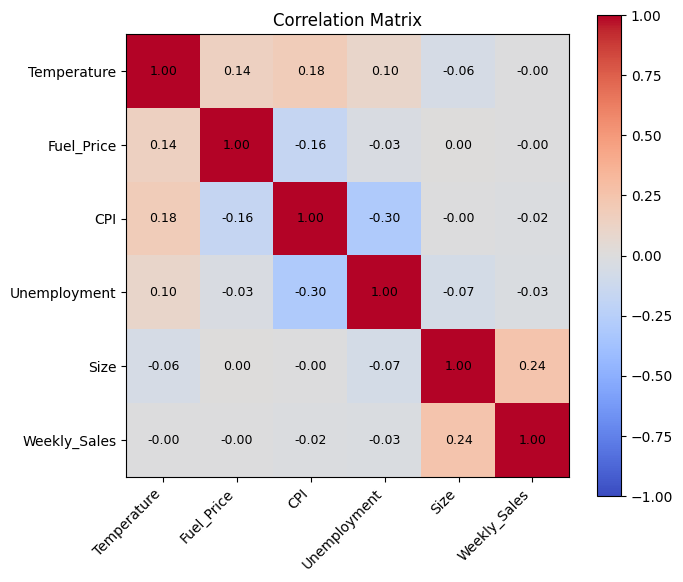

In [13]:
numeric_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'Weekly_Sales']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
VAL_START = pd.Timestamp('2011-11-01')
VAL_END = pd.Timestamp('2012-02-15')

train_df = df[df['Date'] < VAL_START].copy()
val_df = df[(df['Date'] >= VAL_START) & (df['Date'] <= VAL_END)].copy()

print(f"Train: {train_df.shape} | {train_df['Date'].min().date()} -> {train_df['Date'].max().date()}")
print(f"Val:   {val_df.shape} | {val_df['Date'].min().date()} -> {val_df['Date'].max().date()}")
print(f"Holiday კვირები val-ში: {sorted(val_df[val_df['IsHoliday']]['Date'].dt.date.unique())}")

X_train, y_train = train_df.drop(columns=['Weekly_Sales']), train_df['Weekly_Sales']
X_val, y_val = val_df.drop(columns=['Weekly_Sales']), val_df['Weekly_Sales']

Train: (267184, 16) | 2010-02-05 -> 2011-10-28
Val:   (44776, 16) | 2011-11-04 -> 2012-02-10
Holiday კვირები val-ში: [datetime.date(2011, 11, 25), datetime.date(2011, 12, 30), datetime.date(2012, 2, 10)]


In [9]:
class LagFeatureBuilder(BaseEstimator, TransformerMixin):
    def __init__(self, lag_weeks=(51, 52, 53)):
        self.lag_weeks = lag_weeks

    def fit(self, X, y):
        hist = X[['Store', 'Dept', 'Date']].copy()
        hist['Weekly_Sales'] = np.asarray(y)
        self.history_ = hist.drop_duplicates(subset=['Store', 'Dept', 'Date'])
        return self

    def transform(self, X):
        X = X.copy()
        for w in self.lag_weeks:
            shifted = self.history_.copy()
            shifted['Date'] = shifted['Date'] + pd.Timedelta(weeks=w)
            shifted = shifted.rename(columns={'Weekly_Sales': f'Sales_Lag_{w}w'})
            X = X.merge(shifted[['Store', 'Dept', 'Date', f'Sales_Lag_{w}w']],
                        on=['Store', 'Dept', 'Date'], how='left')
        return X

In [10]:
class SeasonalHistFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        tmp = X[['Store', 'Dept', 'Date']].copy()
        tmp['WeekOfYear'] = tmp['Date'].dt.isocalendar().week.astype(int)
        tmp['Weekly_Sales'] = np.asarray(y)

        self.week_means_ = (tmp.groupby(['Store', 'Dept', 'WeekOfYear'])['Weekly_Sales']
                             .mean().reset_index().rename(columns={'Weekly_Sales': 'Hist_Sales'}))
        self.global_mean_ = tmp['Weekly_Sales'].mean()
        return self

    def transform(self, X):
        X = X.copy()
        X['WeekOfYear'] = X['Date'].dt.isocalendar().week.astype(int)
        X = X.merge(self.week_means_, on=['Store', 'Dept', 'WeekOfYear'], how='left')
        X['Hist_Sales'] = X['Hist_Sales'].fillna(self.global_mean_)
        return X

In [11]:
class GroupStatsFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        tmp = X[['Store', 'Dept']].copy()
        tmp['Weekly_Sales'] = np.asarray(y)
        self.group_stats_ = (
            tmp.groupby(['Store', 'Dept'])['Weekly_Sales']
               .agg(Group_Mean='mean', Group_Median='median', Group_Std='std')
               .reset_index()
        )
        return self

    def transform(self, X):
        return X.merge(self.group_stats_, on=['Store', 'Dept'], how='left')

In [12]:
class TemporalFeatureBuilder(BaseEstimator, TransformerMixin):
    TYPE_MAP = {'A': 3, 'B': 2, 'C': 1}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        if 'WeekOfYear' not in X.columns:
            X['WeekOfYear'] = X['Date'].dt.isocalendar().week.astype(int)
        X['IsHoliday'] = X['IsHoliday'].astype(int)
        X['Store_Type'] = X['Type'].map(self.TYPE_MAP)
        X = X.drop(columns=['Date', 'Type'], errors='ignore')
        for col in ['Store', 'Dept', 'Store_Type']:
            X[col] = X[col].astype('category')
        return X

In [13]:
class MissingValueHandler(BaseEstimator, TransformerMixin):
    MARKDOWN_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for c in self.MARKDOWN_COLS:
            if c in X.columns:
                X[c] = X[c].fillna(0)
        for c in ['CPI', 'Unemployment']:
            if c in X.columns:
                X[c] = X.groupby('Store')[c].transform(lambda s: s.ffill().bfill())
        return X

In [14]:
class DropWeakFeatures(BaseEstimator, TransformerMixin):
    WEAK_COLS = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.WEAK_COLS if c in X.columns])

In [15]:
class XGBFinalEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, n_estimators=300, learning_rate=0.05, max_depth=8,
                 subsample=0.85, colsample_bytree=0.85, random_state=42,
                 objective='reg:absoluteerror'):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.random_state = random_state
        self.objective = objective

    def fit(self, X, y, sample_weight=None):
        self.feature_cols_ = list(X.columns)
        self.model_ = xgb.XGBRegressor(
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            max_depth=self.max_depth,
            subsample=self.subsample,
            colsample_bytree=self.colsample_bytree,
            random_state=self.random_state,
            objective=self.objective,
            enable_categorical=True,
            tree_method='hist',
        )
        self.model_.fit(X[self.feature_cols_], y, sample_weight=sample_weight)
        return self

    def predict(self, X):
        return self.model_.predict(X[self.feature_cols_])

In [16]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(weights * np.abs(np.asarray(y_true) - y_pred)) / np.sum(weights)

def evaluate(pipeline, X_tr, y_tr, X_v, y_v):
    pred_tr = pipeline.predict(X_tr)
    pred_v = pipeline.predict(X_v)
    return {
        'mae_train': mean_absolute_error(y_tr, pred_tr),
        'mae_val': mean_absolute_error(y_v, pred_v),
        'wmae_train': wmae(y_tr, pred_tr, X_tr['IsHoliday']),
        'wmae_val': wmae(y_v, pred_v, X_v['IsHoliday']),
    }

def plot_actual_vs_pred(pipeline, train_df_raw, val_df_raw, X_tr, X_v, title):
    pred_tr = pipeline.predict(X_tr)
    pred_v = pipeline.predict(X_v)

    tr_agg = train_df_raw.groupby('Date')['Weekly_Sales'].mean()
    val_agg = val_df_raw.groupby('Date')['Weekly_Sales'].mean()
    pred_tr_agg = pd.DataFrame({'Date': train_df_raw['Date'], 'pred': pred_tr}).groupby('Date')['pred'].mean()
    pred_val_agg = pd.DataFrame({'Date': val_df_raw['Date'], 'pred': pred_v}).groupby('Date')['pred'].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(tr_agg.index, tr_agg.values, color='#4C72B0', label='Actual (Train)')
    ax.plot(val_agg.index, val_agg.values, color='#DD8452', label='Actual (Val)')
    ax.plot(pred_tr_agg.index, pred_tr_agg.values, '--', color='#55A868', alpha=0.7, label='Predicted (Train)')
    ax.plot(pred_val_agg.index, pred_val_agg.values, '--', color='#C44E52', label='Predicted (Val)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [17]:
def log_run(run_name, params, metrics, pipeline=None, registered_name=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        if pipeline is not None:
            mlflow.sklearn.log_model(pipeline, "model", registered_model_name=registered_name)
        print(run_name, "->", metrics)

experiment_log = []

def run_experiment(name, pipeline_steps, X_tr=None, y_tr=None, X_v=None, y_v=None,
                    sample_weight=None, registered_name=None, notes=""):
    X_tr = X_train if X_tr is None else X_tr
    y_tr = y_train if y_tr is None else y_tr
    X_v = X_val if X_v is None else X_v
    y_v = y_val if y_v is None else y_v

    pipe = Pipeline(pipeline_steps)
    if sample_weight is not None:
        pipe.fit(X_tr, y_tr, model__sample_weight=sample_weight)
    else:
        pipe.fit(X_tr, y_tr)
    m = evaluate(pipe, X_tr, y_tr, X_v, y_v)
    experiment_log.append({'run': name, **m, 'notes': notes})
    log_run(name, params={'notes': notes}, metrics=m, pipeline=pipe, registered_name=registered_name)
    return pipe, m

In [18]:
sample_weight_train = np.where(X_train['IsHoliday'], 5, 1)

baseline_pipeline, baseline_metrics = run_experiment(
    "XGBoost_Baseline",
    [
        ('impute', MissingValueHandler()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', XGBFinalEstimator(n_estimators=200, learning_rate=0.1, max_depth=6)),
    ],
    sample_weight=sample_weight_train,
    notes="მხოლოდ temporal + raw features, ლაგების/ისტორიის გარეშე",
)
print(baseline_metrics)

2026/07/11 15:39:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_Baseline -> {'mae_train': 2388.540191722804, 'mae_val': 3737.160883405906, 'wmae_train': np.float64(2549.393121358822), 'wmae_val': np.float64(4140.082949554047)}
🏃 View run XGBoost_Baseline at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1/runs/7d41c4020c15461ca8f5c9e320f54b35
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1
{'mae_train': 2388.540191722804, 'mae_val': 3737.160883405906, 'wmae_train': np.float64(2549.393121358822), 'wmae_val': np.float64(4140.082949554047)}


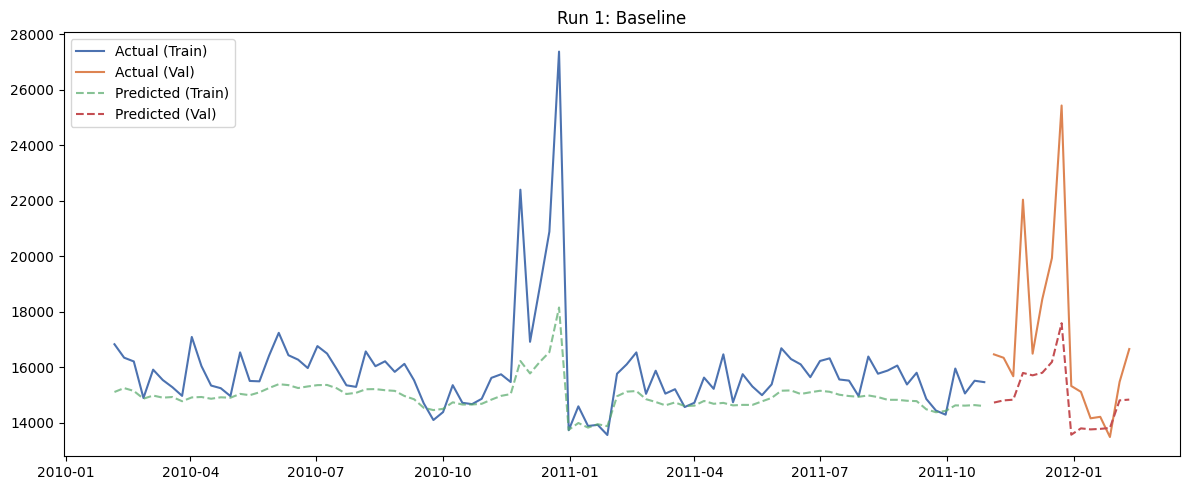

In [19]:
plot_actual_vs_pred(baseline_pipeline, train_df, val_df, X_train, X_val, 'Run 1: Baseline')

In [20]:
lag_pipeline, lag_metrics = run_experiment(
    "XGBoost_LagFeatures",
    [
        ('impute', MissingValueHandler()),
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('temporal', TemporalFeatureBuilder()),
        ('model', XGBFinalEstimator(n_estimators=200, learning_rate=0.1, max_depth=6)),
    ],
    sample_weight=sample_weight_train,
    notes="+ წინა წლის იმავე კვირის გაყიდვა",
)
print(lag_metrics)

2026/07/11 15:40:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_LagFeatures -> {'mae_train': 2372.9645290717203, 'mae_val': 2559.227364940716, 'wmae_train': np.float64(2525.594902862218), 'wmae_val': np.float64(2988.5473932651516)}
🏃 View run XGBoost_LagFeatures at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1/runs/359d7947de4d42f790b8b20451db0285
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1
{'mae_train': 2372.9645290717203, 'mae_val': 2559.227364940716, 'wmae_train': np.float64(2525.594902862218), 'wmae_val': np.float64(2988.5473932651516)}


In [21]:
full_pipeline, full_metrics = run_experiment(
    "XGBoost_SeasonalAndGroupStats",
    [
        ('impute', MissingValueHandler()),
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('seasonal_hist', SeasonalHistFeatureBuilder()),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', XGBFinalEstimator(n_estimators=300, learning_rate=0.08, max_depth=7)),
    ],
    sample_weight=sample_weight_train,
    notes="+ Store+Dept+WeekOfYear historical mean + Store+Dept group stats",
)
print(full_metrics)

2026/07/11 15:41:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_SeasonalAndGroupStats -> {'mae_train': 623.7826947013136, 'mae_val': 2574.485536735837, 'wmae_train': np.float64(622.2360183944909), 'wmae_val': np.float64(2862.855788402001)}
🏃 View run XGBoost_SeasonalAndGroupStats at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1/runs/fd85c2d9bd9a4092901aa6f127858ef4
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1
{'mae_train': 623.7826947013136, 'mae_val': 2574.485536735837, 'wmae_train': np.float64(622.2360183944909), 'wmae_val': np.float64(2862.855788402001)}


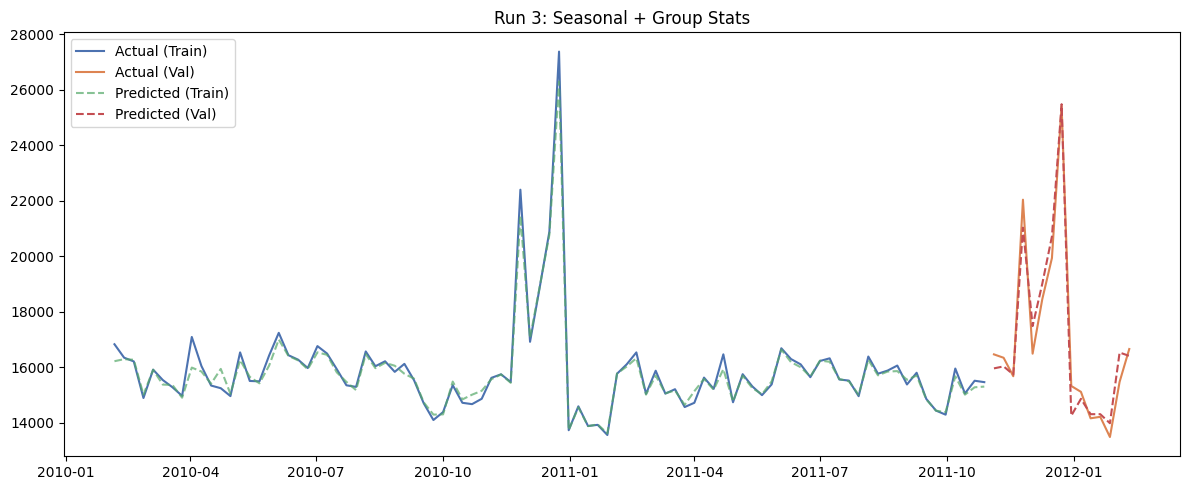

In [22]:
plot_actual_vs_pred(full_pipeline, train_df, val_df, X_train, X_val, 'Run 3: Seasonal + Group Stats')

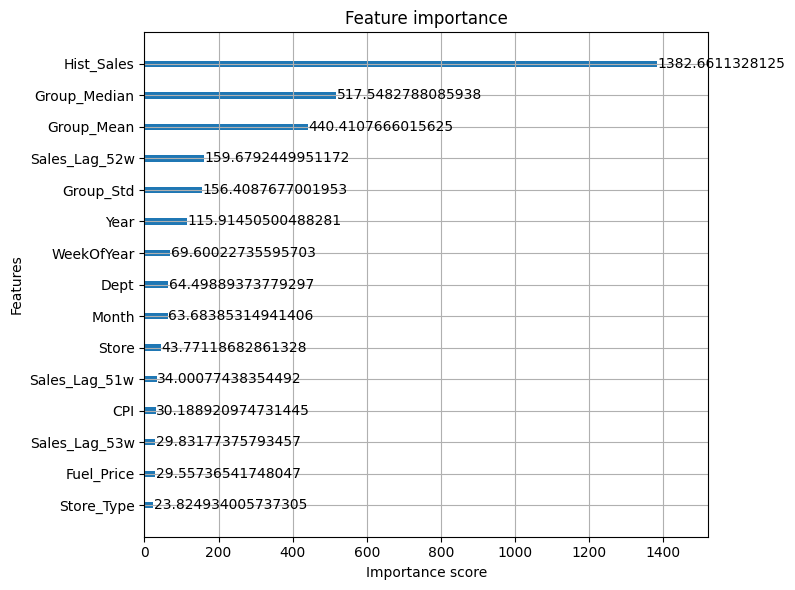

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
xgb.plot_importance(full_pipeline.named_steps['model'].model_, importance_type='gain',
                     max_num_features=15, ax=ax)
plt.tight_layout()
plt.show()

In [24]:
_, dropweak_metrics = run_experiment(
    "XGBoost_DropWeakExternalFeatures",
    [
        ('impute', MissingValueHandler()),
        ('drop_weak', DropWeakFeatures()),
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('seasonal_hist', SeasonalHistFeatureBuilder()),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', XGBFinalEstimator(n_estimators=300, learning_rate=0.08, max_depth=7)),
    ],
    sample_weight=sample_weight_train,
    notes="Temperature/Fuel_Price/CPI/Unemployment მოცილებული",
)
print(dropweak_metrics)
print("(შედარებისთვის) სრული feature-set (Run 3):", full_metrics)

2026/07/11 15:42:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_DropWeakExternalFeatures -> {'mae_train': 618.2355519467083, 'mae_val': 2524.3706524820695, 'wmae_train': np.float64(628.4278771101178), 'wmae_val': np.float64(2826.746193453228)}
🏃 View run XGBoost_DropWeakExternalFeatures at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1/runs/ca6e69b0575b4b8aa16027203c9ae4a9
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1
{'mae_train': 618.2355519467083, 'mae_val': 2524.3706524820695, 'wmae_train': np.float64(628.4278771101178), 'wmae_val': np.float64(2826.746193453228)}
(შედარებისთვის) სრული feature-set (Run 3): {'mae_train': 623.7826947013136, 'mae_val': 2574.485536735837, 'wmae_train': np.float64(622.2360183944909), 'wmae_val': np.float64(2862.855788402001)}


In [26]:
hp_grid = [
    {'learning_rate': 0.08, 'n_estimators': 300, 'max_depth': 6},
    {'learning_rate': 0.05, 'n_estimators': 500, 'max_depth': 8},
    {'learning_rate': 0.03, 'n_estimators': 800, 'max_depth': 9},
]
hp_results = []

for params in hp_grid:
    pipe = Pipeline([
        ('impute', MissingValueHandler()),
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('seasonal_hist', SeasonalHistFeatureBuilder()),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', XGBFinalEstimator(random_state=42, **params)),
    ])
    pipe.fit(X_train, y_train, model__sample_weight=sample_weight_train)
    m = evaluate(pipe, X_train, y_train, X_val, y_val)
    print(params, '->', m)
    hp_results.append((params, m, pipe))

{'learning_rate': 0.08, 'n_estimators': 300, 'max_depth': 6} -> {'mae_train': 677.5043856003942, 'mae_val': 2569.2251037940714, 'wmae_train': np.float64(689.7788571178746), 'wmae_val': np.float64(2867.3614486178344)}
{'learning_rate': 0.05, 'n_estimators': 500, 'max_depth': 8} -> {'mae_train': 555.0411603814683, 'mae_val': 2542.559317121356, 'wmae_train': np.float64(546.7370887955741), 'wmae_val': np.float64(2809.1679167784746)}
{'learning_rate': 0.03, 'n_estimators': 800, 'max_depth': 9} -> {'mae_train': 512.9703088775985, 'mae_val': 2522.7721507886745, 'wmae_train': np.float64(499.93705557234637), 'wmae_val': np.float64(2811.550583879137)}


In [27]:
for params, m, pipe in hp_results:
    run_name = f"XGBoost_HPO_lr{params['learning_rate']}_depth{params['max_depth']}"
    log_run(run_name, params=params, metrics=m, pipeline=pipe)

best_params, best_metrics, best_pipeline = min(hp_results, key=lambda r: r[1]['wmae_val'])
print("საუკეთესო კონფიგურაცია:", best_params, best_metrics)

2026/07/11 15:49:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_HPO_lr0.08_depth6 -> {'mae_train': 677.5043856003942, 'mae_val': 2569.2251037940714, 'wmae_train': np.float64(689.7788571178746), 'wmae_val': np.float64(2867.3614486178344)}
🏃 View run XGBoost_HPO_lr0.08_depth6 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1/runs/263dfdb2ed4945bf812c0f817bbf9ff9
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1


2026/07/11 15:49:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_HPO_lr0.05_depth8 -> {'mae_train': 555.0411603814683, 'mae_val': 2542.559317121356, 'wmae_train': np.float64(546.7370887955741), 'wmae_val': np.float64(2809.1679167784746)}
🏃 View run XGBoost_HPO_lr0.05_depth8 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1/runs/e6ad5f11b86e4e1e82dbcc8dc2717cf3
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1


2026/07/11 15:49:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_HPO_lr0.03_depth9 -> {'mae_train': 512.9703088775985, 'mae_val': 2522.7721507886745, 'wmae_train': np.float64(499.93705557234637), 'wmae_val': np.float64(2811.550583879137)}
🏃 View run XGBoost_HPO_lr0.03_depth9 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1/runs/ba964af04511485088ae40d8e6580aba
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1
საუკეთესო კონფიგურაცია: {'learning_rate': 0.05, 'n_estimators': 500, 'max_depth': 8} {'mae_train': 555.0411603814683, 'mae_val': 2542.559317121356, 'wmae_train': np.float64(546.7370887955741), 'wmae_val': np.float64(2809.1679167784746)}


In [28]:
rng = np.random.RandomState(42)
y_train_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)

_, shuffled_metrics = run_experiment(
    "XGBoost_ShuffledTarget_SanityCheck",
    [
        ('impute', MissingValueHandler()),
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('seasonal_hist', SeasonalHistFeatureBuilder()),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', XGBFinalEstimator(n_estimators=300, learning_rate=0.08, max_depth=7)),
    ],
    y_tr=y_train_shuffled,
    sample_weight=sample_weight_train,
    notes="SANITY CHECK: y_train შემთხვევითად არეული — მოდელს არაფრის სწავლა არ უნდა შეეძლოს",
)
print("Shuffled-target (უნდა იყოს ცუდი):", shuffled_metrics)
print("(შედარებისთვის) ნამდვილი target (Run 3):", full_metrics)

2026/07/11 15:50:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_ShuffledTarget_SanityCheck -> {'mae_train': 4398.479022448712, 'mae_val': 20195.26121468092, 'wmae_train': np.float64(4151.1005181997325), 'wmae_val': np.float64(20474.79303555732)}
🏃 View run XGBoost_ShuffledTarget_SanityCheck at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1/runs/d1ccf65099504f51b6a15071e49efffe
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1
Shuffled-target (უნდა იყოს ცუდი): {'mae_train': 4398.479022448712, 'mae_val': 20195.26121468092, 'wmae_train': np.float64(4151.1005181997325), 'wmae_val': np.float64(20474.79303555732)}
(შედარებისთვის) ნამდვილი target (Run 3): {'mae_train': 623.7826947013136, 'mae_val': 2574.485536735837, 'wmae_train': np.float64(622.2360183944909), 'wmae_val': np.float64(2862.855788402001)}


                               run     wmae_val
  XGBoost_DropWeakExternalFeatures  2826.746193
     XGBoost_SeasonalAndGroupStats  2862.855788
               XGBoost_LagFeatures  2988.547393
                  XGBoost_Baseline  4140.082950
XGBoost_ShuffledTarget_SanityCheck 20474.793036


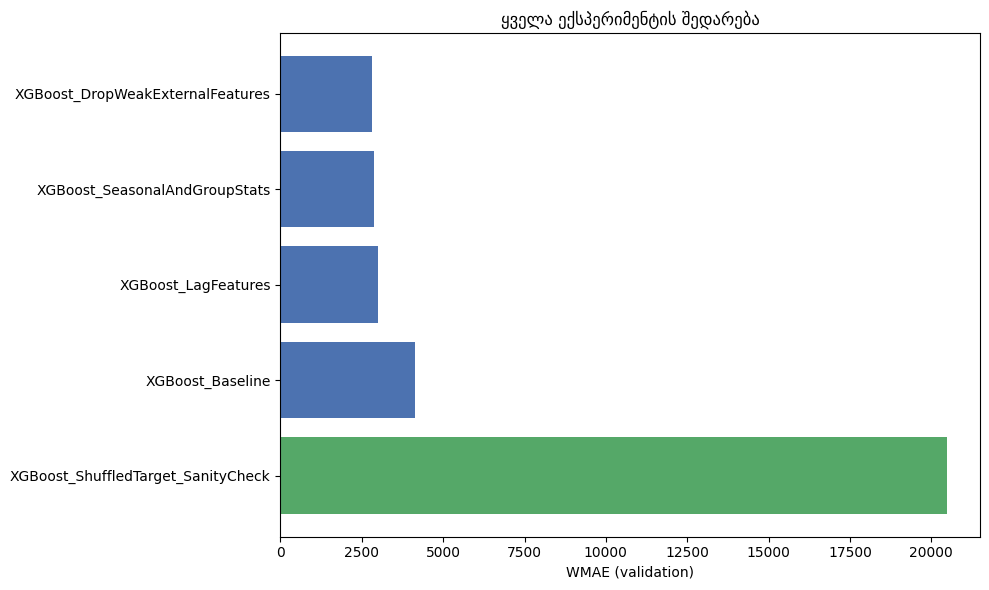

In [29]:
summary_df = pd.DataFrame(experiment_log)[['run', 'wmae_val']].sort_values('wmae_val')
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#55A868' if 'Sanity' in r else '#4C72B0' for r in summary_df['run']]
ax.barh(summary_df['run'], summary_df['wmae_val'], color=colors)
ax.set_xlabel('WMAE (validation)')
ax.set_title('ყველა ექსპერიმენტის შედარება')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
X_full, y_full = df.drop(columns=['Weekly_Sales']), df['Weekly_Sales']
sample_weight_full = np.where(X_full['IsHoliday'], 5, 1)

final_pipeline = Pipeline([
    ('impute', MissingValueHandler()),
    ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
    ('seasonal_hist', SeasonalHistFeatureBuilder()),
    ('group_stats', GroupStatsFeatureBuilder()),
    ('temporal', TemporalFeatureBuilder()),
    ('model', XGBFinalEstimator(random_state=42, **best_params)),
])

final_pipeline.fit(X_full, y_full, model__sample_weight=sample_weight_full)
final_metrics = evaluate(final_pipeline, X_train, y_train, X_val, y_val)
print("საბოლოო მოდელის მეტრიკები (X_train/X_val-ზე, sanity-შემოწმებისთვის):", final_metrics)

საბოლოო მოდელის მეტრიკები (X_train/X_val-ზე, sanity-შემოწმებისთვის): {'mae_train': 871.6281020649375, 'mae_val': 625.109753520709, 'wmae_train': np.float64(869.4888802684904), 'wmae_val': np.float64(623.6063534291961)}


In [31]:
log_run(
    "XGBoost_Final_FullDataFit",
    params={'best_params': best_params, 'trained_on': 'full_dataset'},
    metrics=final_metrics,
    pipeline=final_pipeline,
    registered_name="Walmart_XGBoost_SalesForecast",
)

2026/07/11 15:53:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'Walmart_XGBoost_SalesForecast' already exists. Creating a new version of this model...
2026/07/11 15:53:37 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Walmart_XGBoost_SalesForecast, version 2
Created version '2' of model 'Walmart_XGBoost_SalesForecast'.


XGBoost_Final_FullDataFit -> {'mae_train': 871.6281020649375, 'mae_val': 625.109753520709, 'wmae_train': np.float64(869.4888802684904), 'wmae_val': np.float64(623.6063534291961)}
🏃 View run XGBoost_Final_FullDataFit at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1/runs/9fdf0d6c88d24af68c8e8b711916064c
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/1
